# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_pM_fold,max_pE_fold,T_pM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
2,0.0,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.00000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000e+00,0.0,0.000000
110,0.0,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.00000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000e+00,0.0,0.000000
218,0.0,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.00000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000e+00,0.0,0.000000
326,0.0,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.00000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000e+00,0.0,0.000000
434,0.0,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.00000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000e+00,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33546964,0.1,0.01,10000000.0,1000000.0,10000000.0,1000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302724e+06,60.973434,0.342170,0.693147,0.000000,0.0,20.0,1.03825,0.00,0.243472,1.122877,0.000165,6.028338e+06,6.698971,-4.090746e+10,0.0,0.000030
33547072,0.1,0.01,10000000.0,1000000.0,10000000.0,1000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302706e+06,84.026046,0.375693,0.695145,0.000000,0.0,20.0,1.15129,-0.03,0.243470,1.122875,0.000220,6.028356e+06,6.698971,-4.090746e+10,0.0,0.000042
33547180,0.1,0.01,10000000.0,1000000.0,10000000.0,1000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.302387e+06,448.903956,0.944295,0.721249,0.000000,0.0,20.0,4.67508,-0.34,0.243449,1.122830,0.001495,6.028664e+06,6.698971,-4.090746e+10,0.0,0.000224
33547288,0.1,0.01,10000000.0,1000000.0,10000000.0,1000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.287633e+06,8987.207509,2.843338,2.788647,8.489491,0.0,20.0,8.44849,-7.12,0.242479,1.120583,0.085587,6.042754e+06,6.698971,-4.090746e+10,0.0,0.004494


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

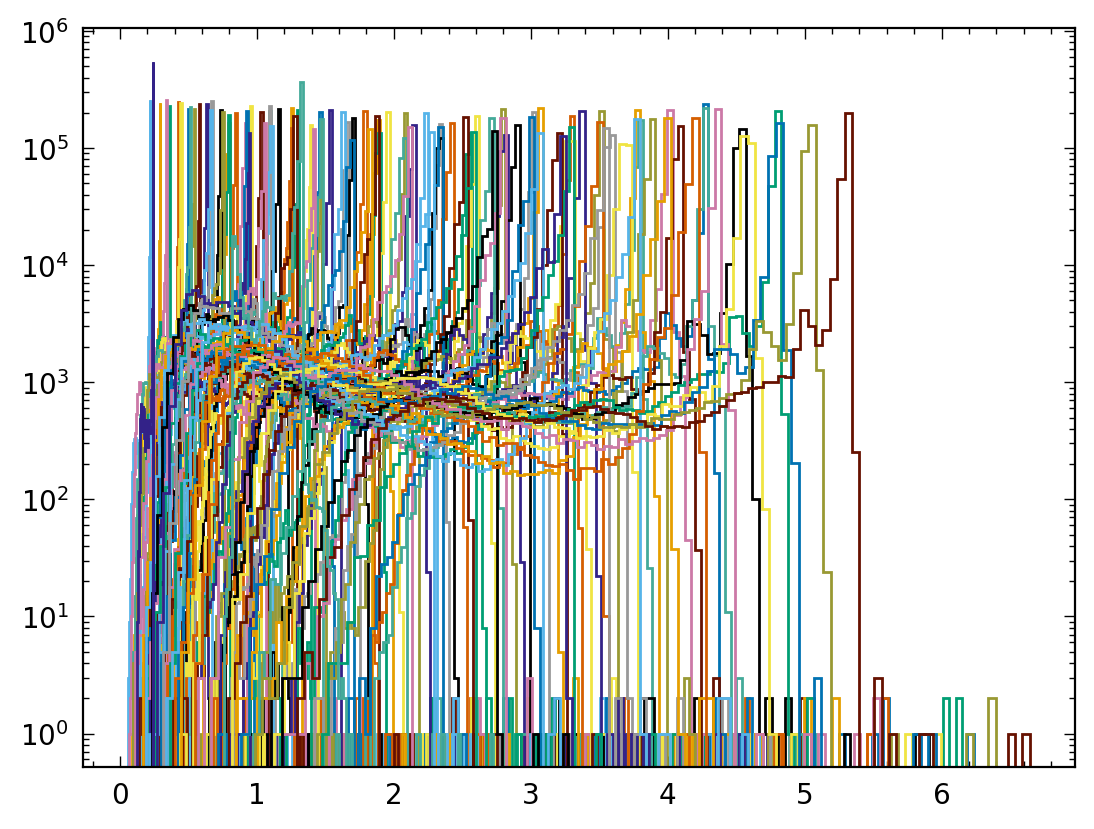

In [7]:
# Inspect distribution of observables
sel = 'stim_pI'
for a in np.unique(clustered_mean_df[key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,0.698970,0.213863,1.188207,0.058724
1,0.716313,0.284544,1.371517,0.097591
2,0.734707,0.352728,1.497191,0.134626
3,0.754414,0.420099,1.584585,0.172537
4,0.754888,0.331615,1.178710,0.097014
...,...,...,...,...
97,2.568202,4.537636,1.632763,0.546075
98,2.676694,4.805343,1.659988,0.576142
99,2.812913,5.099120,1.660383,0.599527
100,6.698971,0.240337,1.114748,0.103268


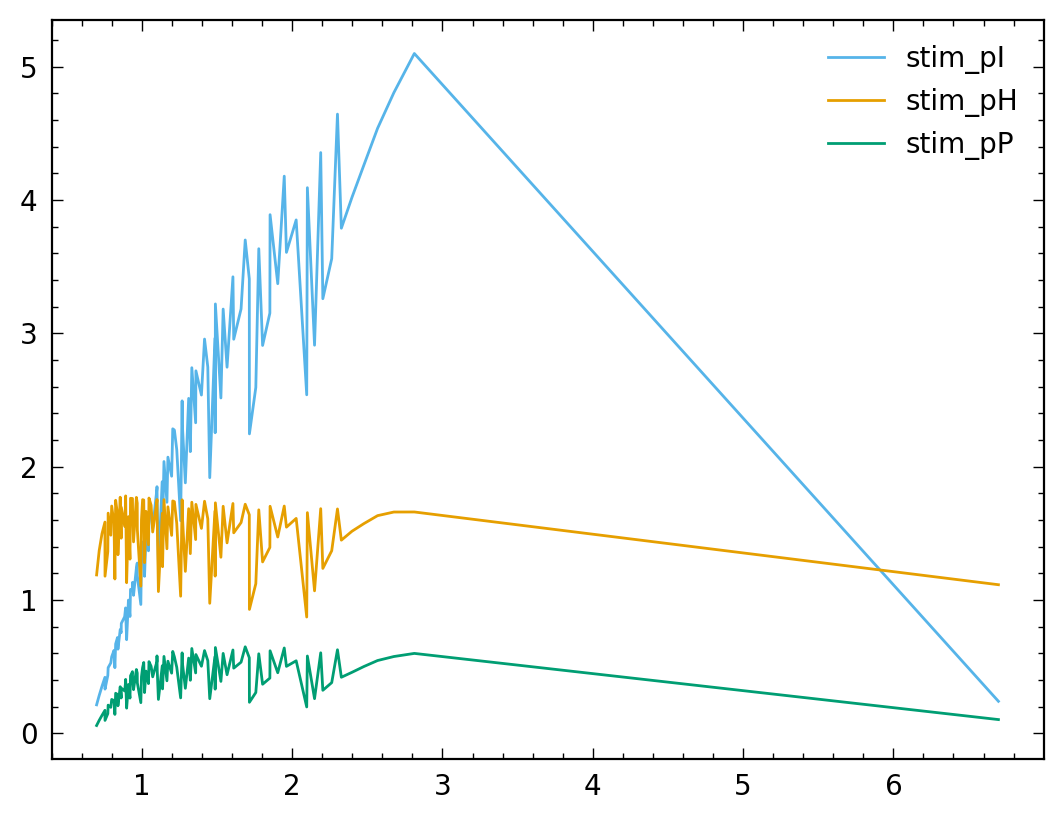

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 9
fevals: 12
fevals: 13
fevals: 14


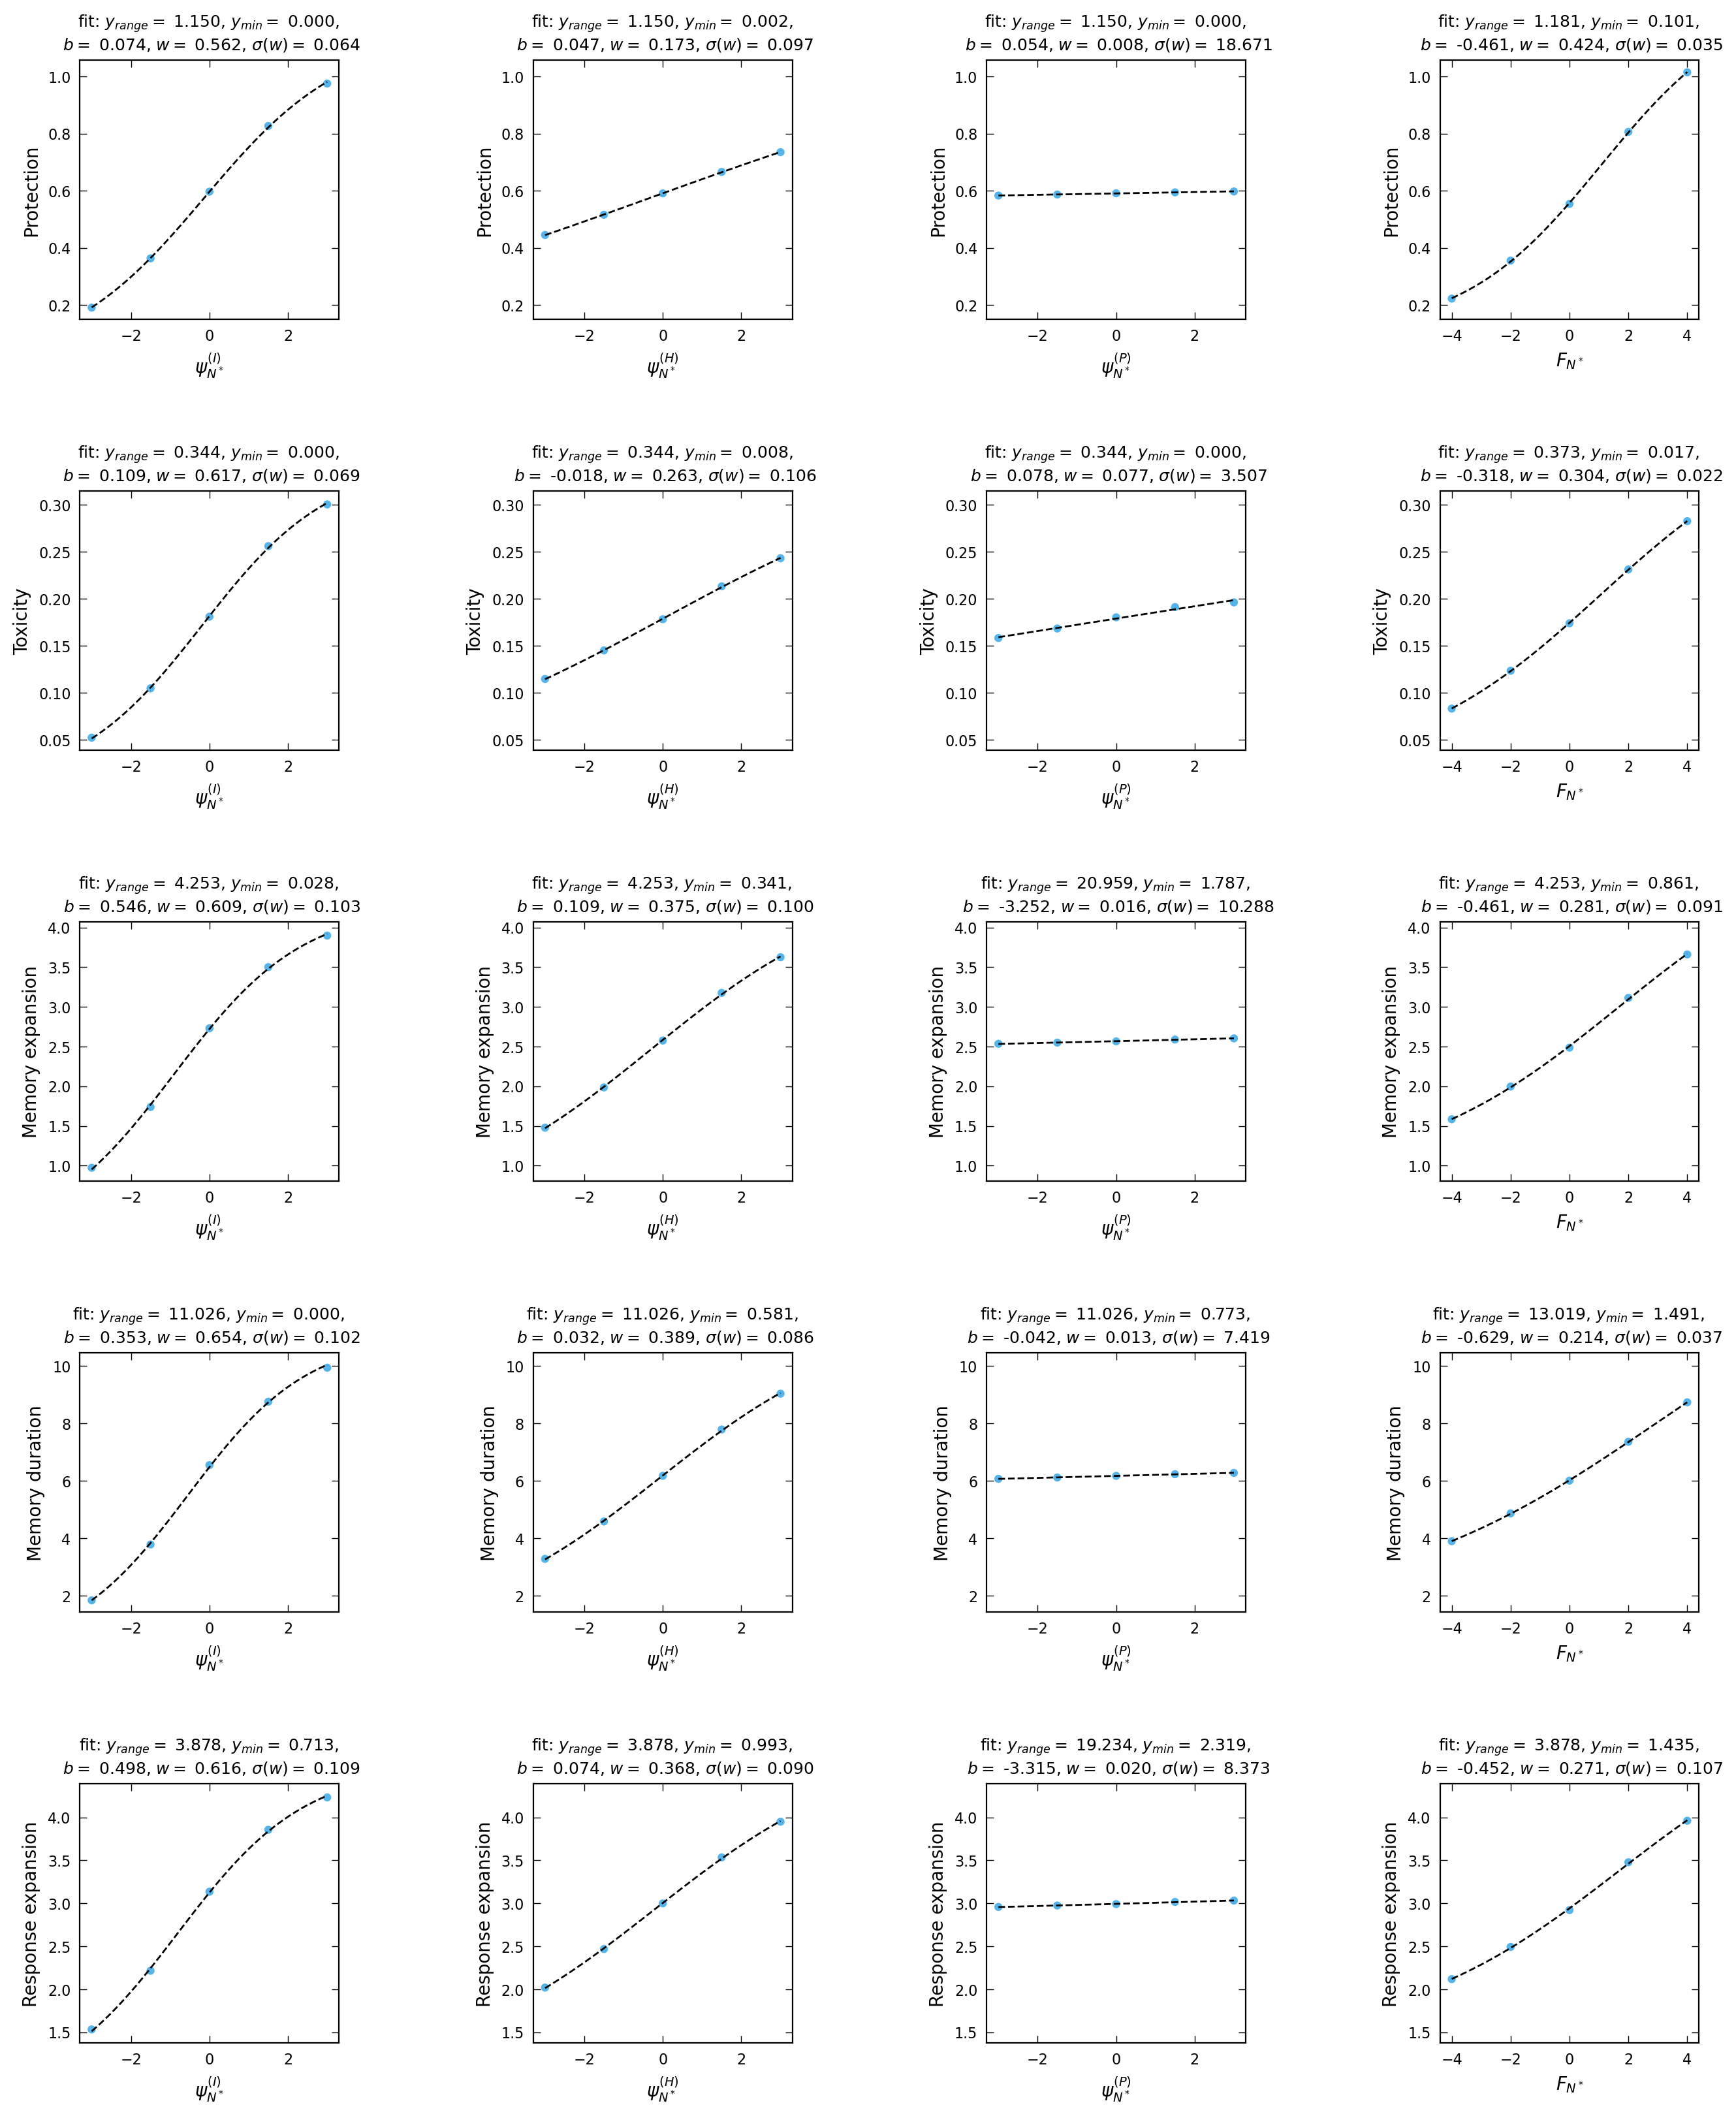

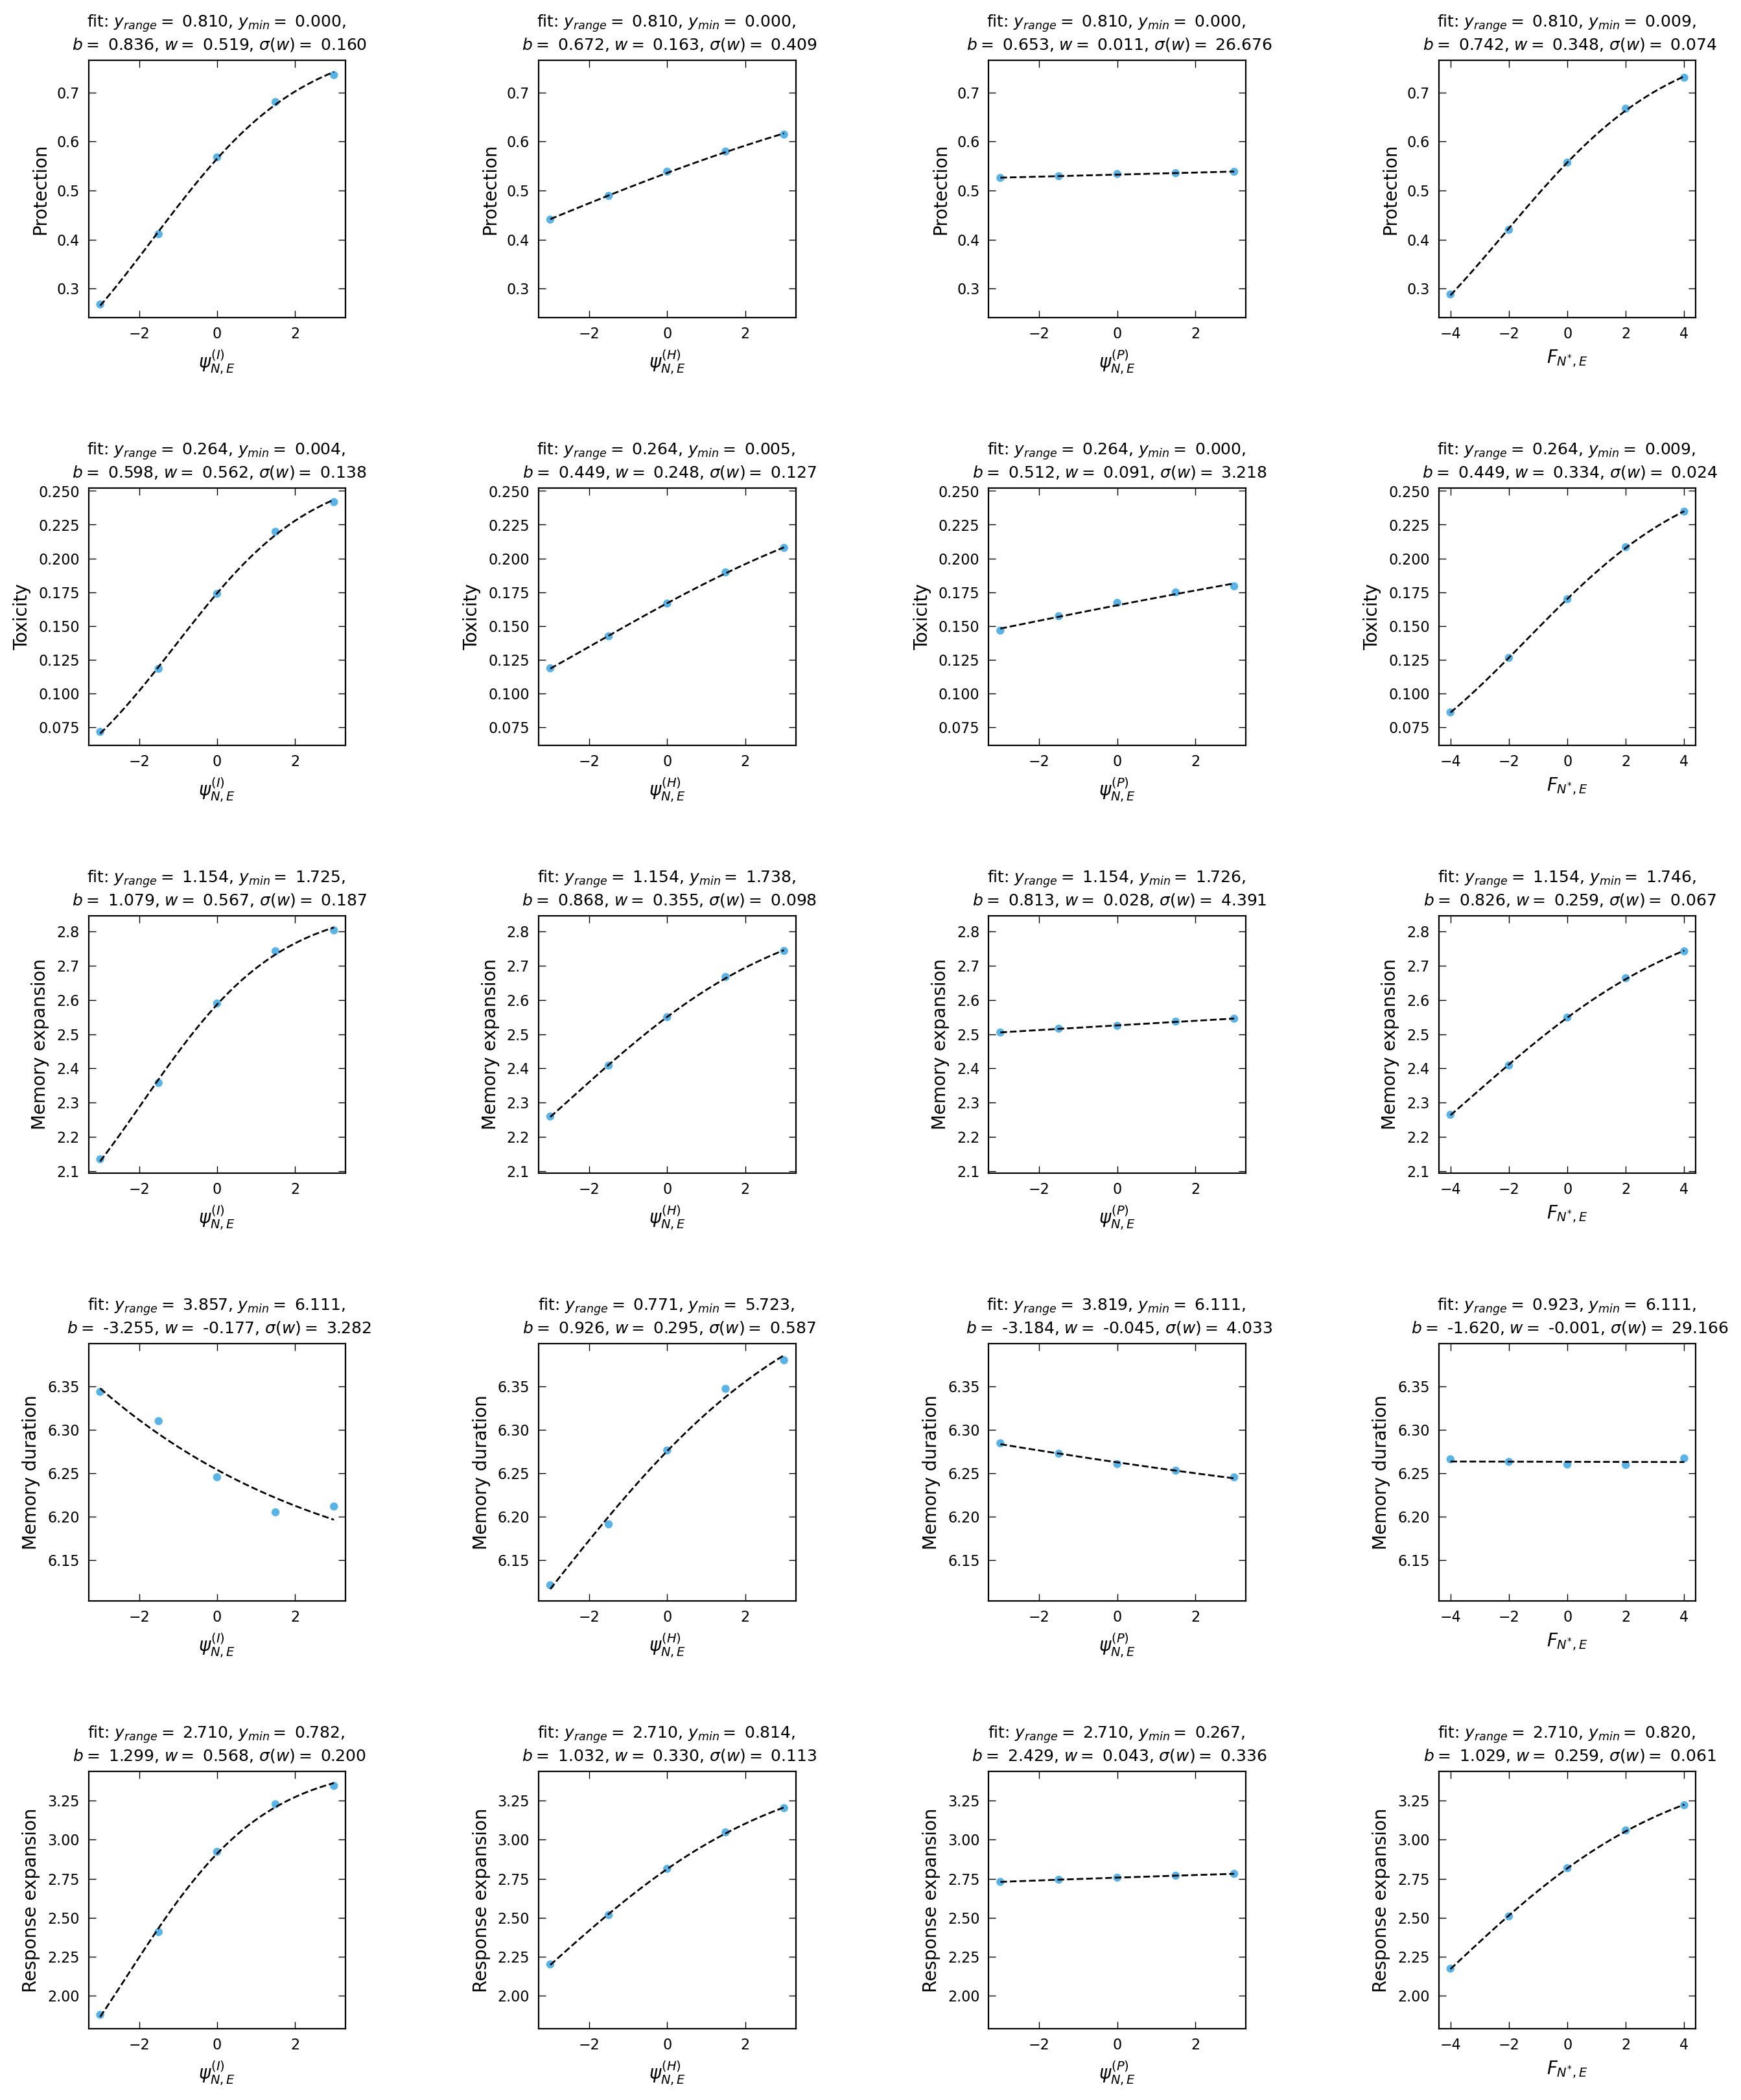

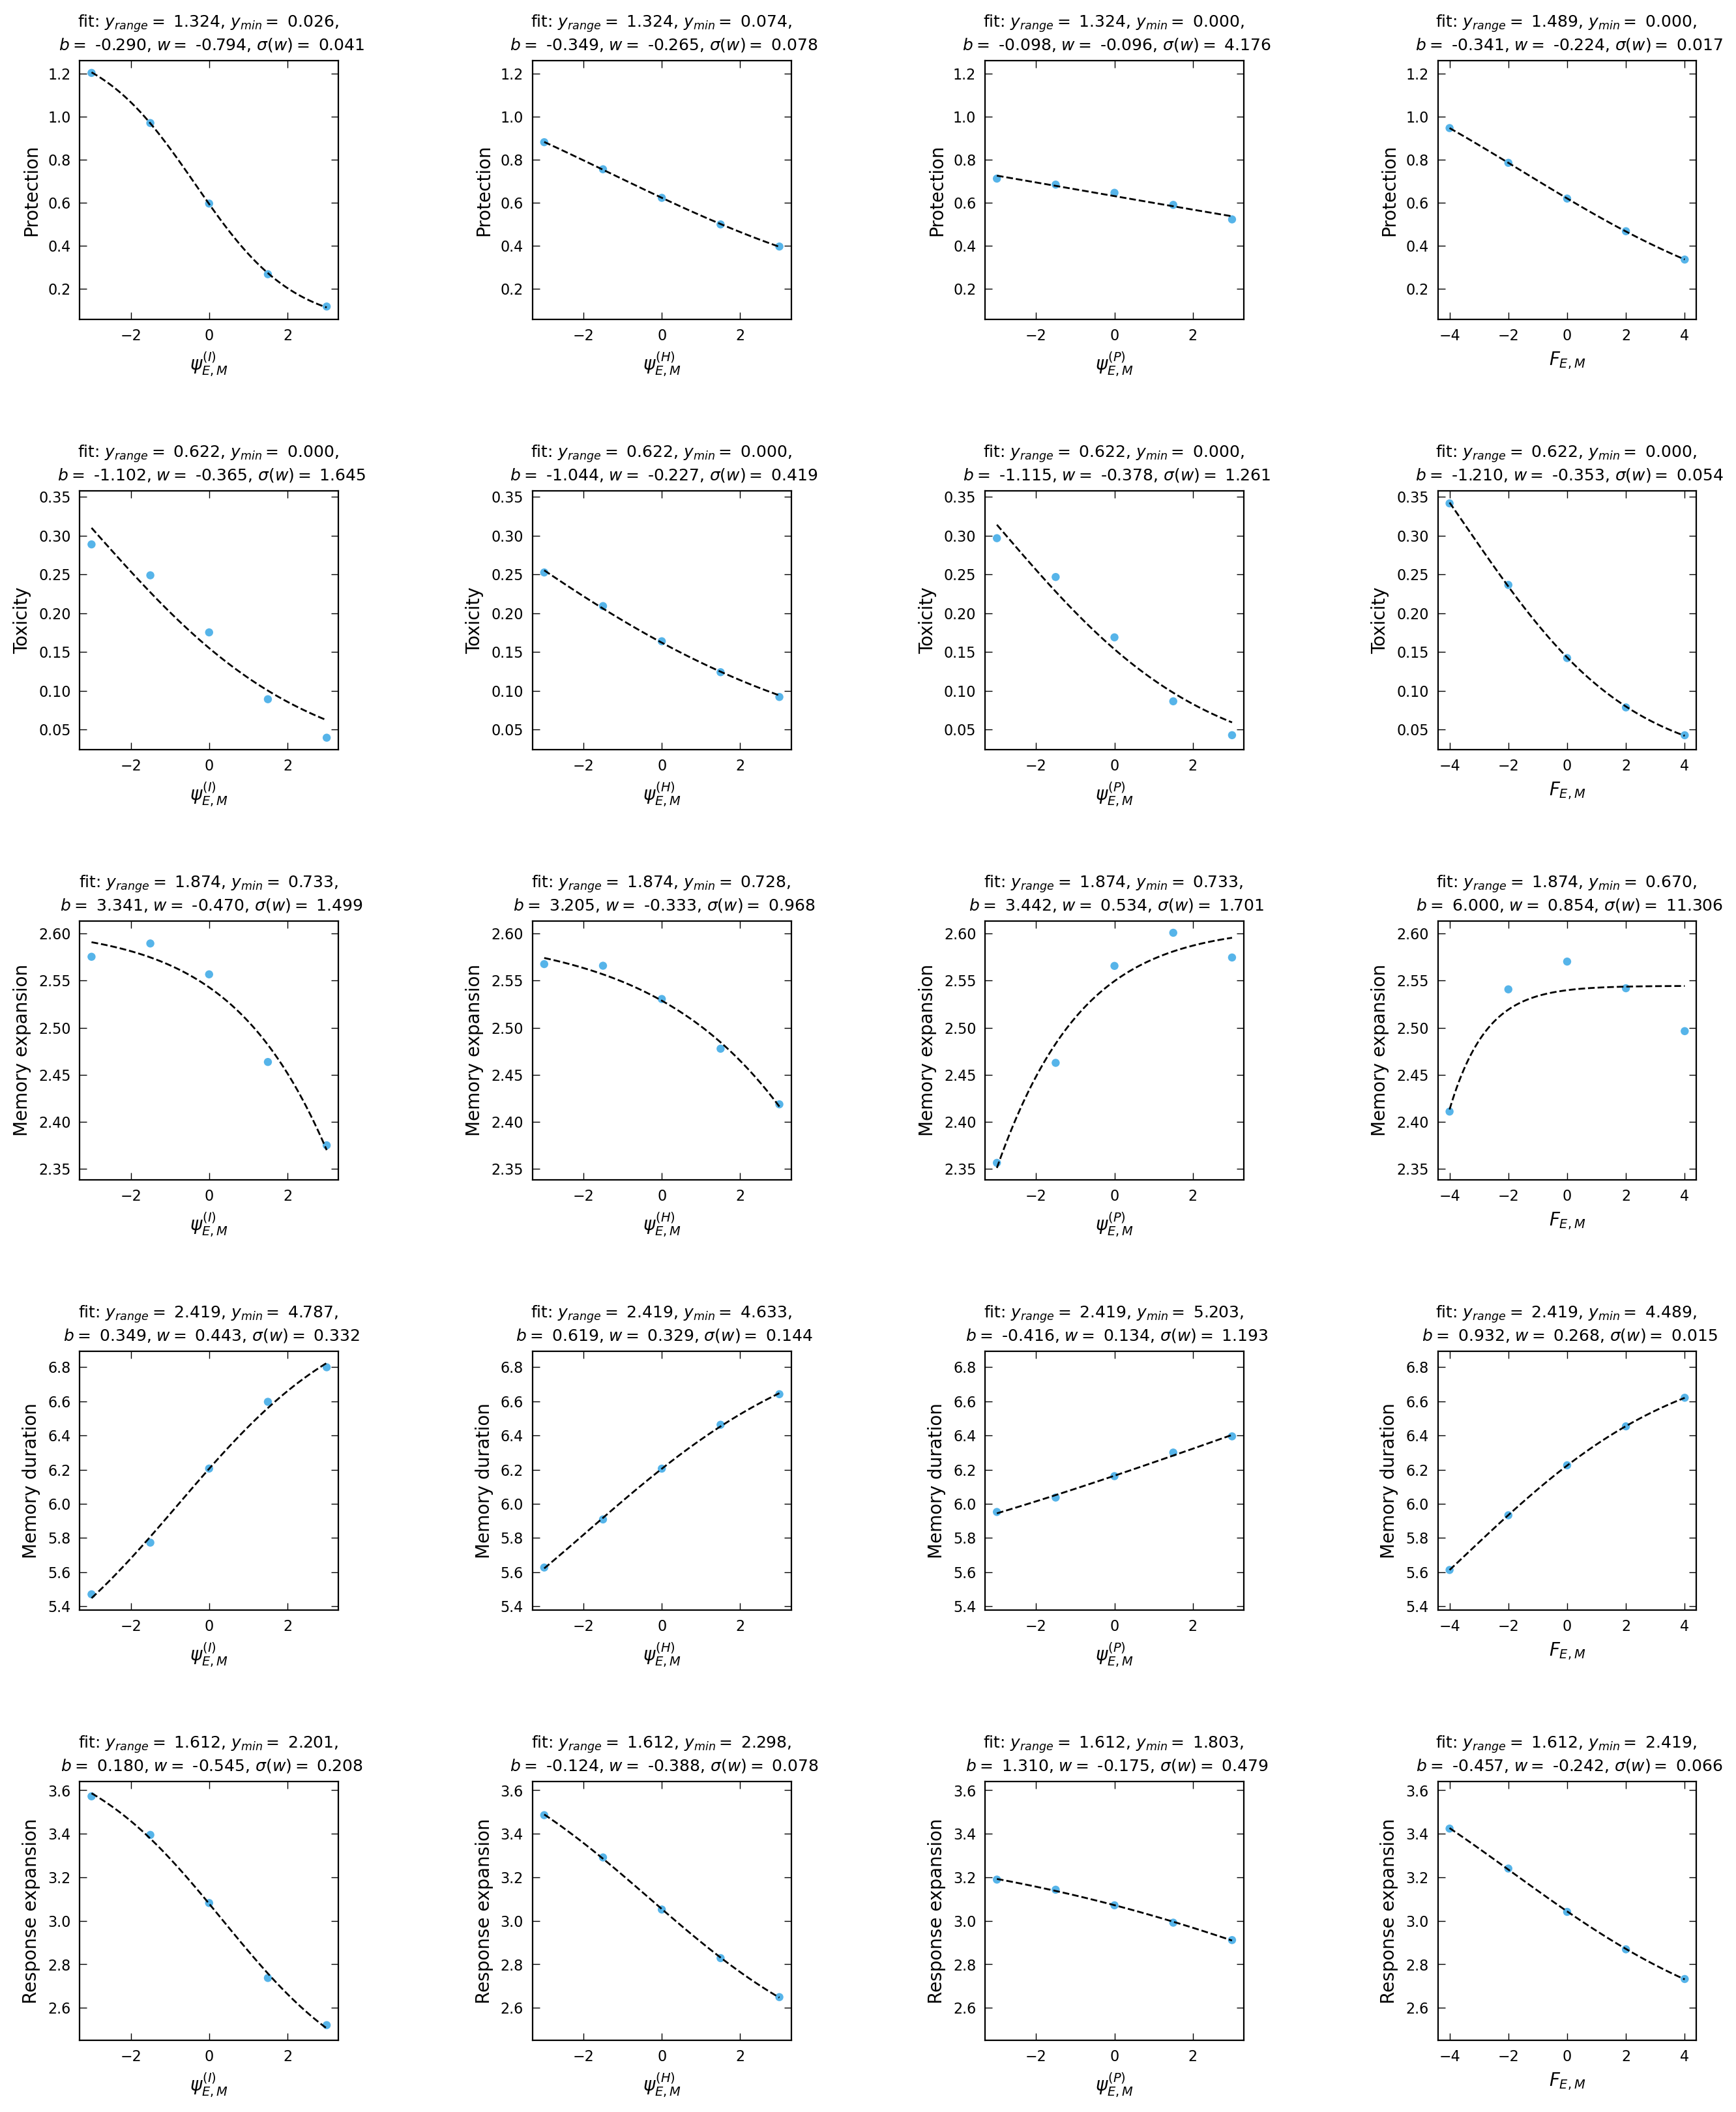

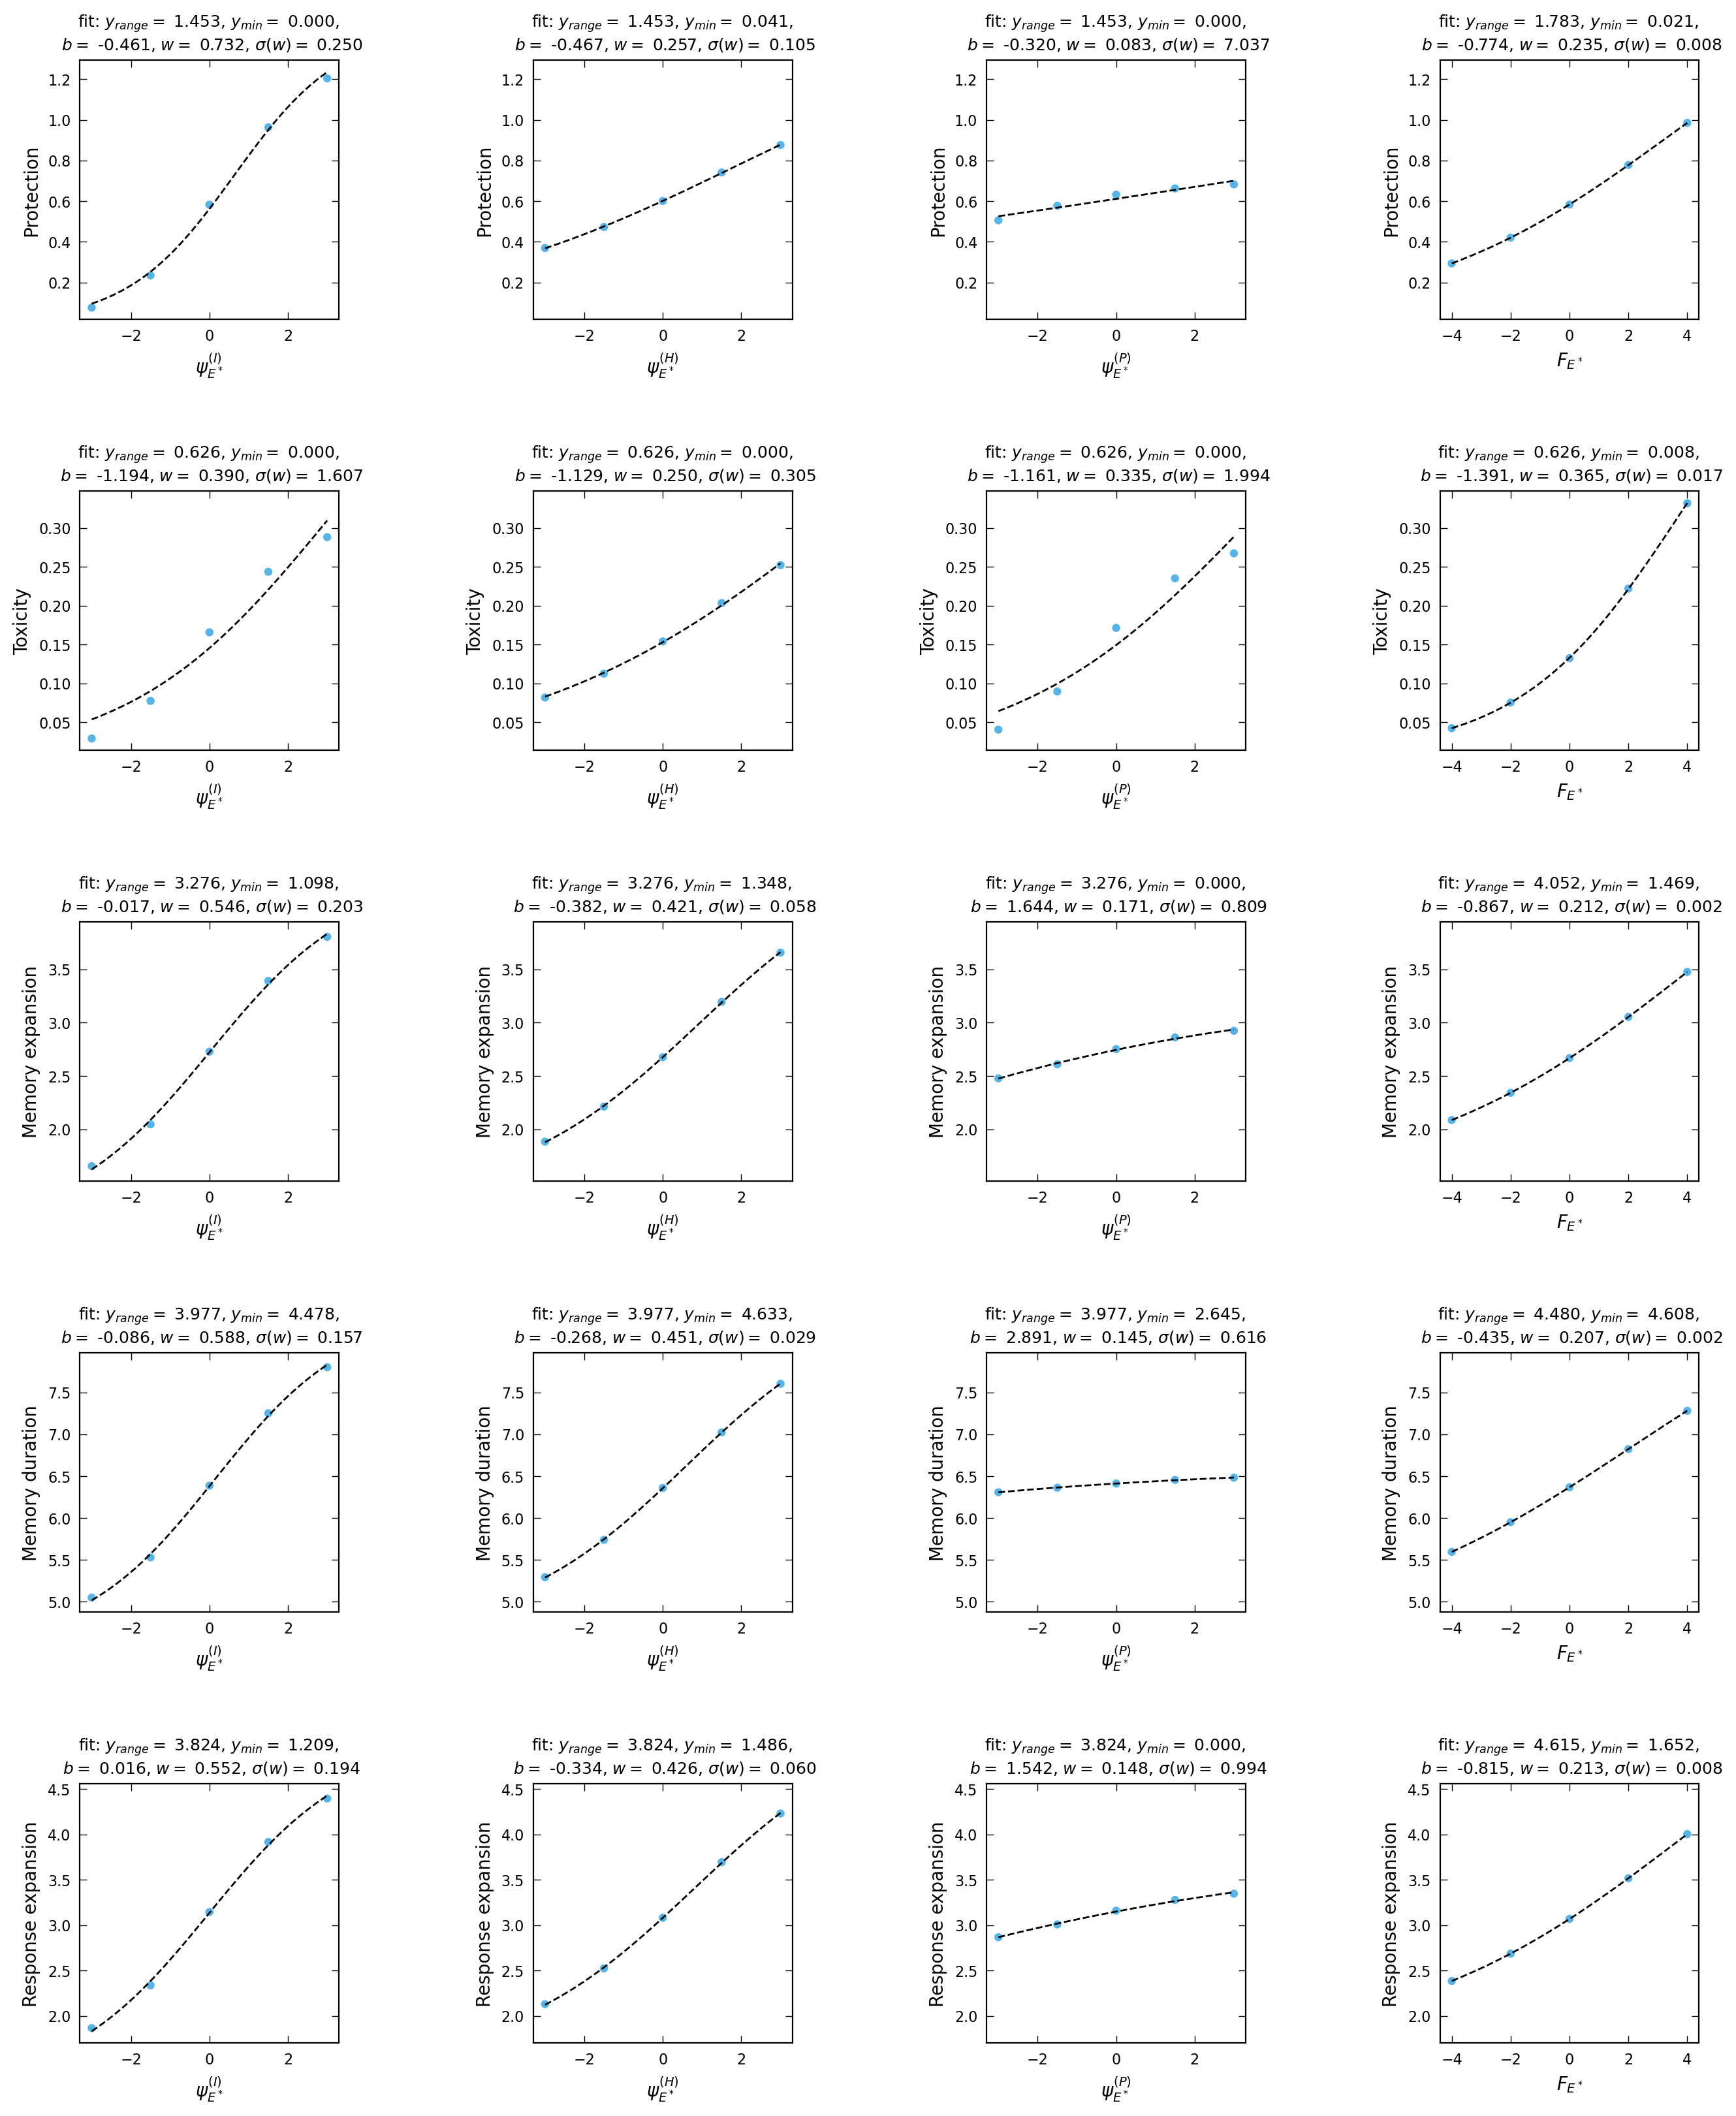

In [8]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[clustered_mean_df.K_EH == K_EH].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [9]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [32]:
# Regress Performance measures on regulation parameters
num_cpu = 108
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0 if y_min > 0.0 else y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_min, 0.0] + len(variables)*[-2.5*F0_max] + num_modules*[-3.0*F0_max], 
                                     [2.0*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[2.5*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [33]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [64]:
# View result
perf = 3 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
3,16.719947,6.310639e-21,1.257575,0.149690,0.118501,1.842657,0.253711,0.036467,0.032230,0.429361,0.224221,0.011684,0.230351,0.482592,0.450389,0.039645,0.036810,0.673886,0.423769,1.609503,2.346647,-0.717991,0.036497,0.003265,0.007126,0.003372,0.003345,0.009441,0.002574,0.002321,0.002319,0.002430,0.003226,0.003030,0.003236,0.003547,0.002058,0.001564,0.001564,0.001900,0.003797,0.010417,0.015109,0.003135,0.01,10000000.0,0.000000e+00,50000.0,300.0,10000000.0,0.0,2.281849,12.566132,0.0,0.000000,3.0,1.123444,3.517882,0.000000e+00,0.687654,0.060883,0.292531,NaN
8,7.650977,1.645361e-35,0.354333,0.191838,0.004498,2.845914,0.186140,0.000711,0.021636,1.017933,0.175343,0.001120,0.246553,1.075485,0.379820,0.023307,0.037169,3.283771,-4.732611,1.373516,3.690566,-12.000000,0.024990,0.000351,0.002302,0.002199,0.002148,0.021069,0.001984,0.001944,0.001945,0.002208,0.002483,0.002439,0.002524,0.003105,0.003336,0.001383,0.001397,0.027603,0.041788,0.004590,0.011478,0.107738,0.01,50000000.0,0.000000e+00,50000.0,300.0,10000000.0,0.0,0.208247,7.650977,0.0,0.000000,3.0,0.181771,0.894784,0.000000e+00,0.180540,0.060883,0.003880,NaN
13,16.757592,4.911467e-19,1.039616,0.639557,0.117813,1.572204,0.241344,0.145027,0.028521,0.438888,0.219786,0.051327,0.207487,0.487310,0.438869,0.170430,0.037849,0.682281,0.557078,1.596953,2.374493,-0.728352,0.037049,0.003492,0.005285,0.004141,0.003264,0.006312,0.002604,0.002460,0.002375,0.002447,0.003330,0.003149,0.003310,0.003713,0.002104,0.001698,0.001621,0.001990,0.004148,0.010353,0.015774,0.003210,0.05,10000000.0,0.000000e+00,50000.0,300.0,10000000.0,0.0,2.324220,12.691849,0.0,0.000000,3.0,1.163624,3.539056,0.000000e+00,0.665597,0.267120,0.324858,NaN
18,8.331586,1.828367e-14,0.348952,0.691654,0.000535,2.640451,0.179309,0.001540,0.021664,0.987207,0.155498,0.005656,0.277983,0.996792,0.378965,0.146208,0.050981,3.332395,-4.084863,1.531864,3.475866,-12.000000,0.020935,0.000361,0.002293,0.002631,0.002095,0.007310,0.001730,0.001695,0.001696,0.001943,0.002114,0.002081,0.002181,0.002612,0.002925,0.001596,0.001370,0.022294,0.013687,0.004357,0.009696,0.086227,0.05,50000000.0,0.000000e+00,50000.0,300.0,10000000.0,0.0,0.248927,8.331586,0.0,0.000000,3.0,0.187263,1.044510,0.000000e+00,0.173276,0.267120,0.006105,NaN
23,38.956097,8.354324e-37,4.001928,1.115447,0.075302,1.045938,-0.087833,-0.009680,-0.006678,-0.063820,0.282140,0.051279,0.082165,0.184257,0.202085,0.042526,0.008629,0.105341,1.146408,0.381042,1.827483,0.638602,1.293832,0.010564,0.015857,0.005848,0.003977,0.003302,0.004210,0.001132,0.001084,0.002994,0.004293,0.002579,0.002682,0.003076,0.003276,0.001396,0.001254,0.001689,0.005055,0.078729,0.022756,0.024399,0.25,10000.0,1.500000e-07,50000.0,300.0,10000000.0,1000.0,7.447791,19.478049,0.0,8.859359,3.0,2.284546,5.923584,5.383736e+00,5.099120,1.660383,0.599527,2.812913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,13.843286,3.909826e-16,1.032287,3.927106,0.052132,2.378979,0.239079,0.915074,0.029903,0.543321,0.147675,0.638530,0.251974,0.505655,0.688629,2.611305,0.038896,1.418193,0.876281,1.629842,2.124451,-1.912182,0.014429,0.001693,0.005663,0.017330,0.

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

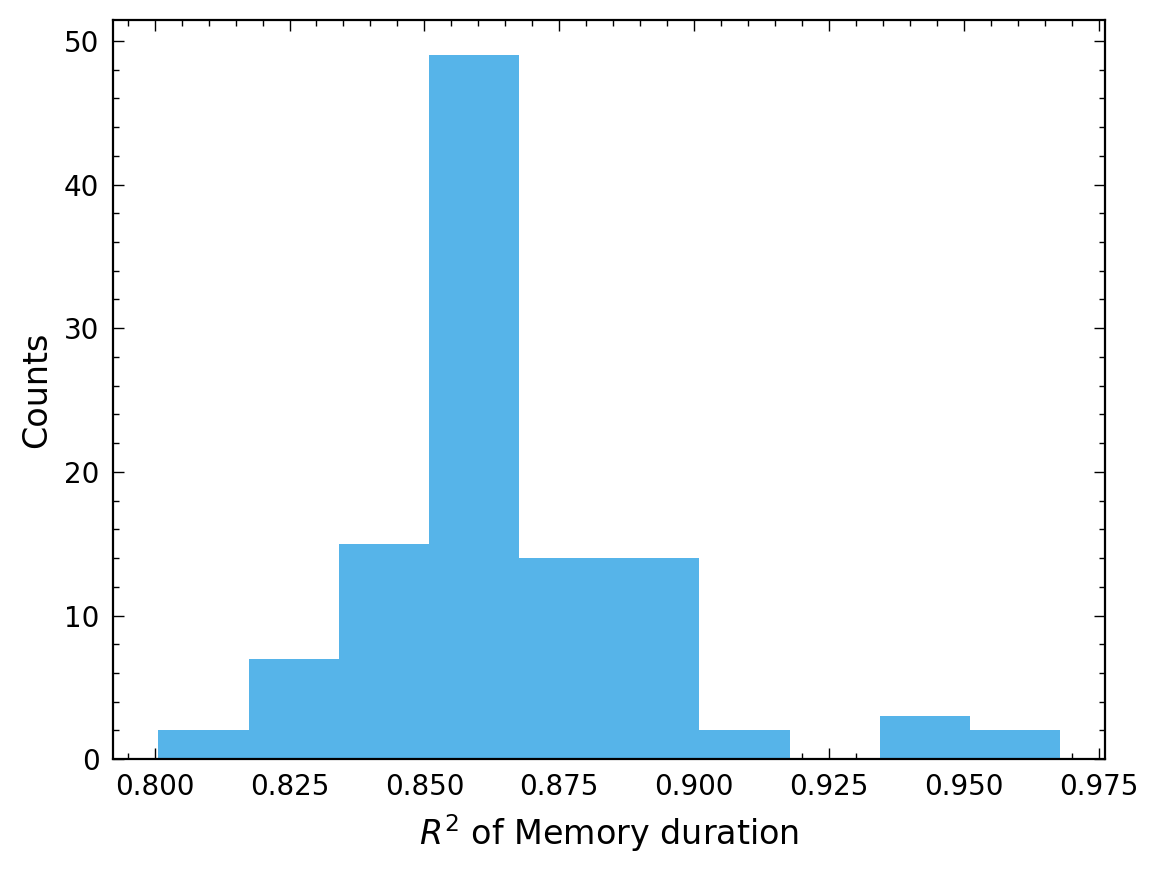

In [65]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

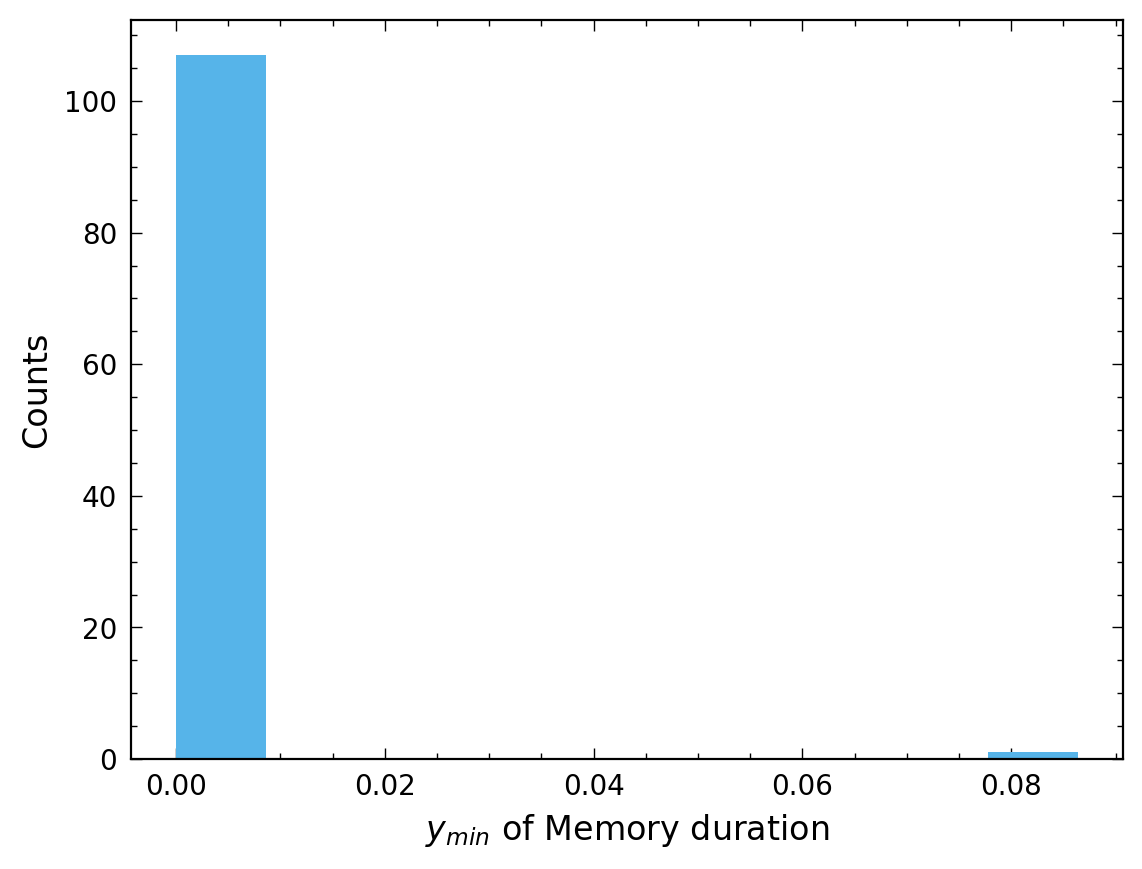

In [66]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

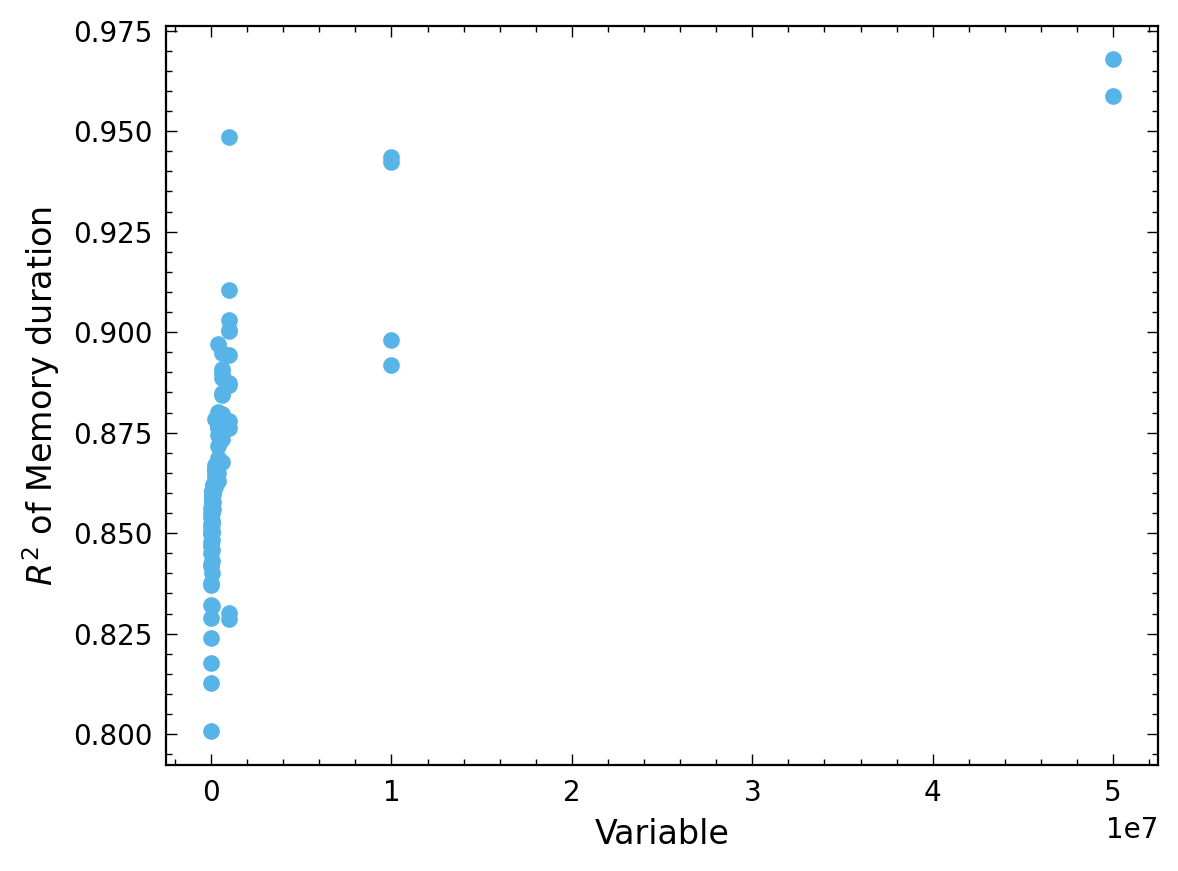

In [67]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].K_IE, model_r_sq);
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

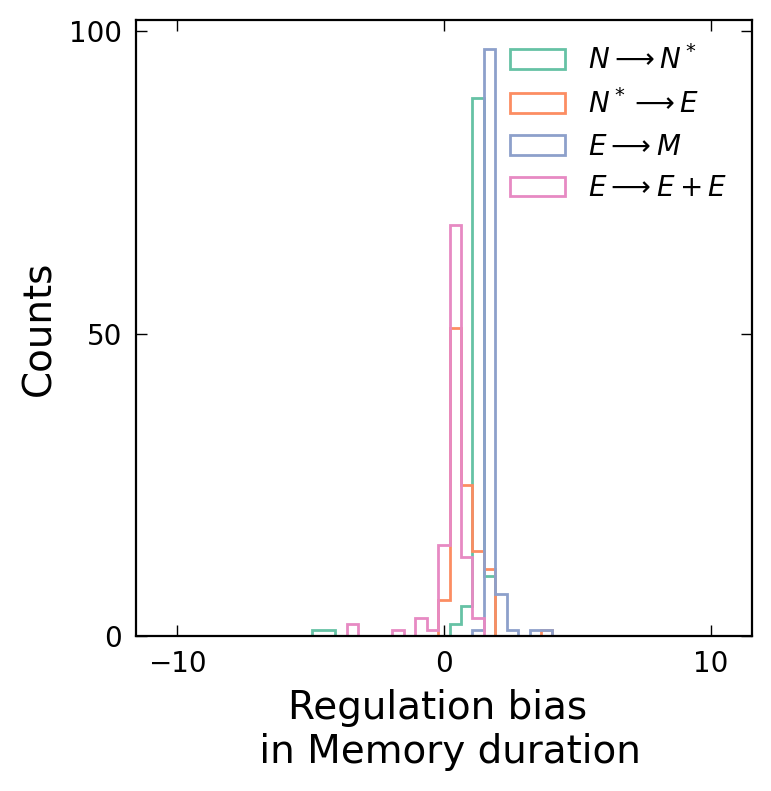

In [68]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

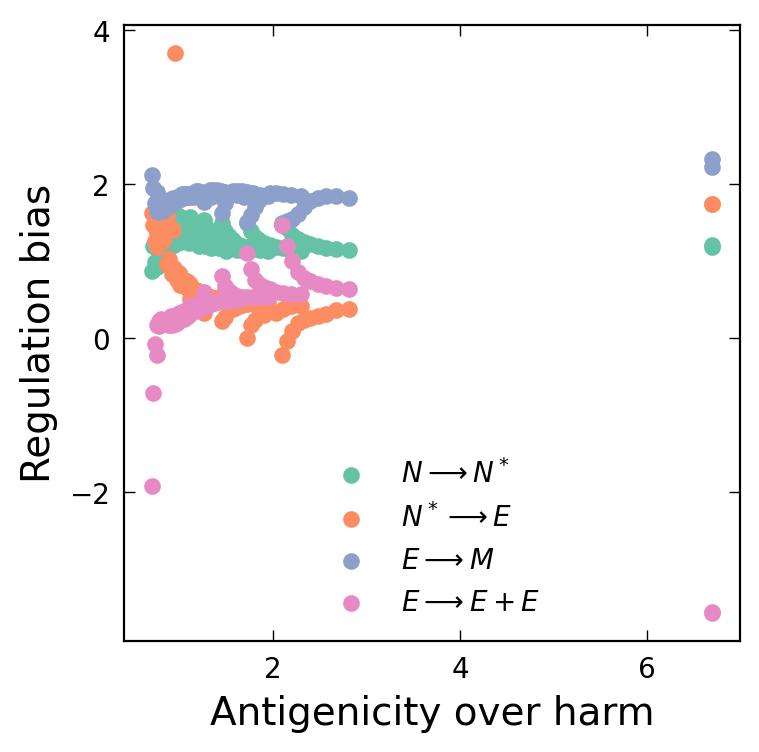

In [69]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

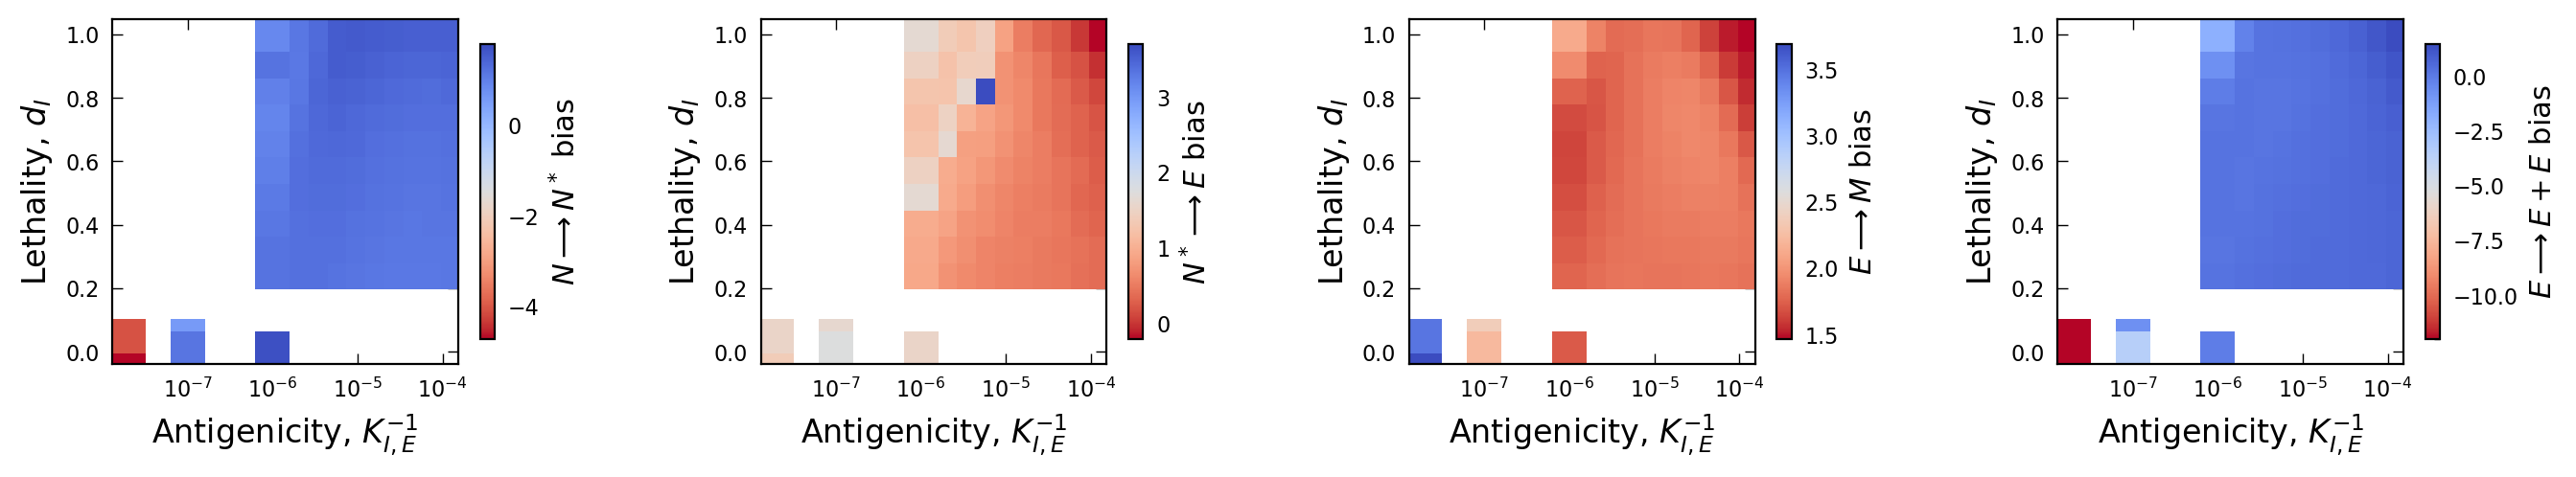

In [70]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

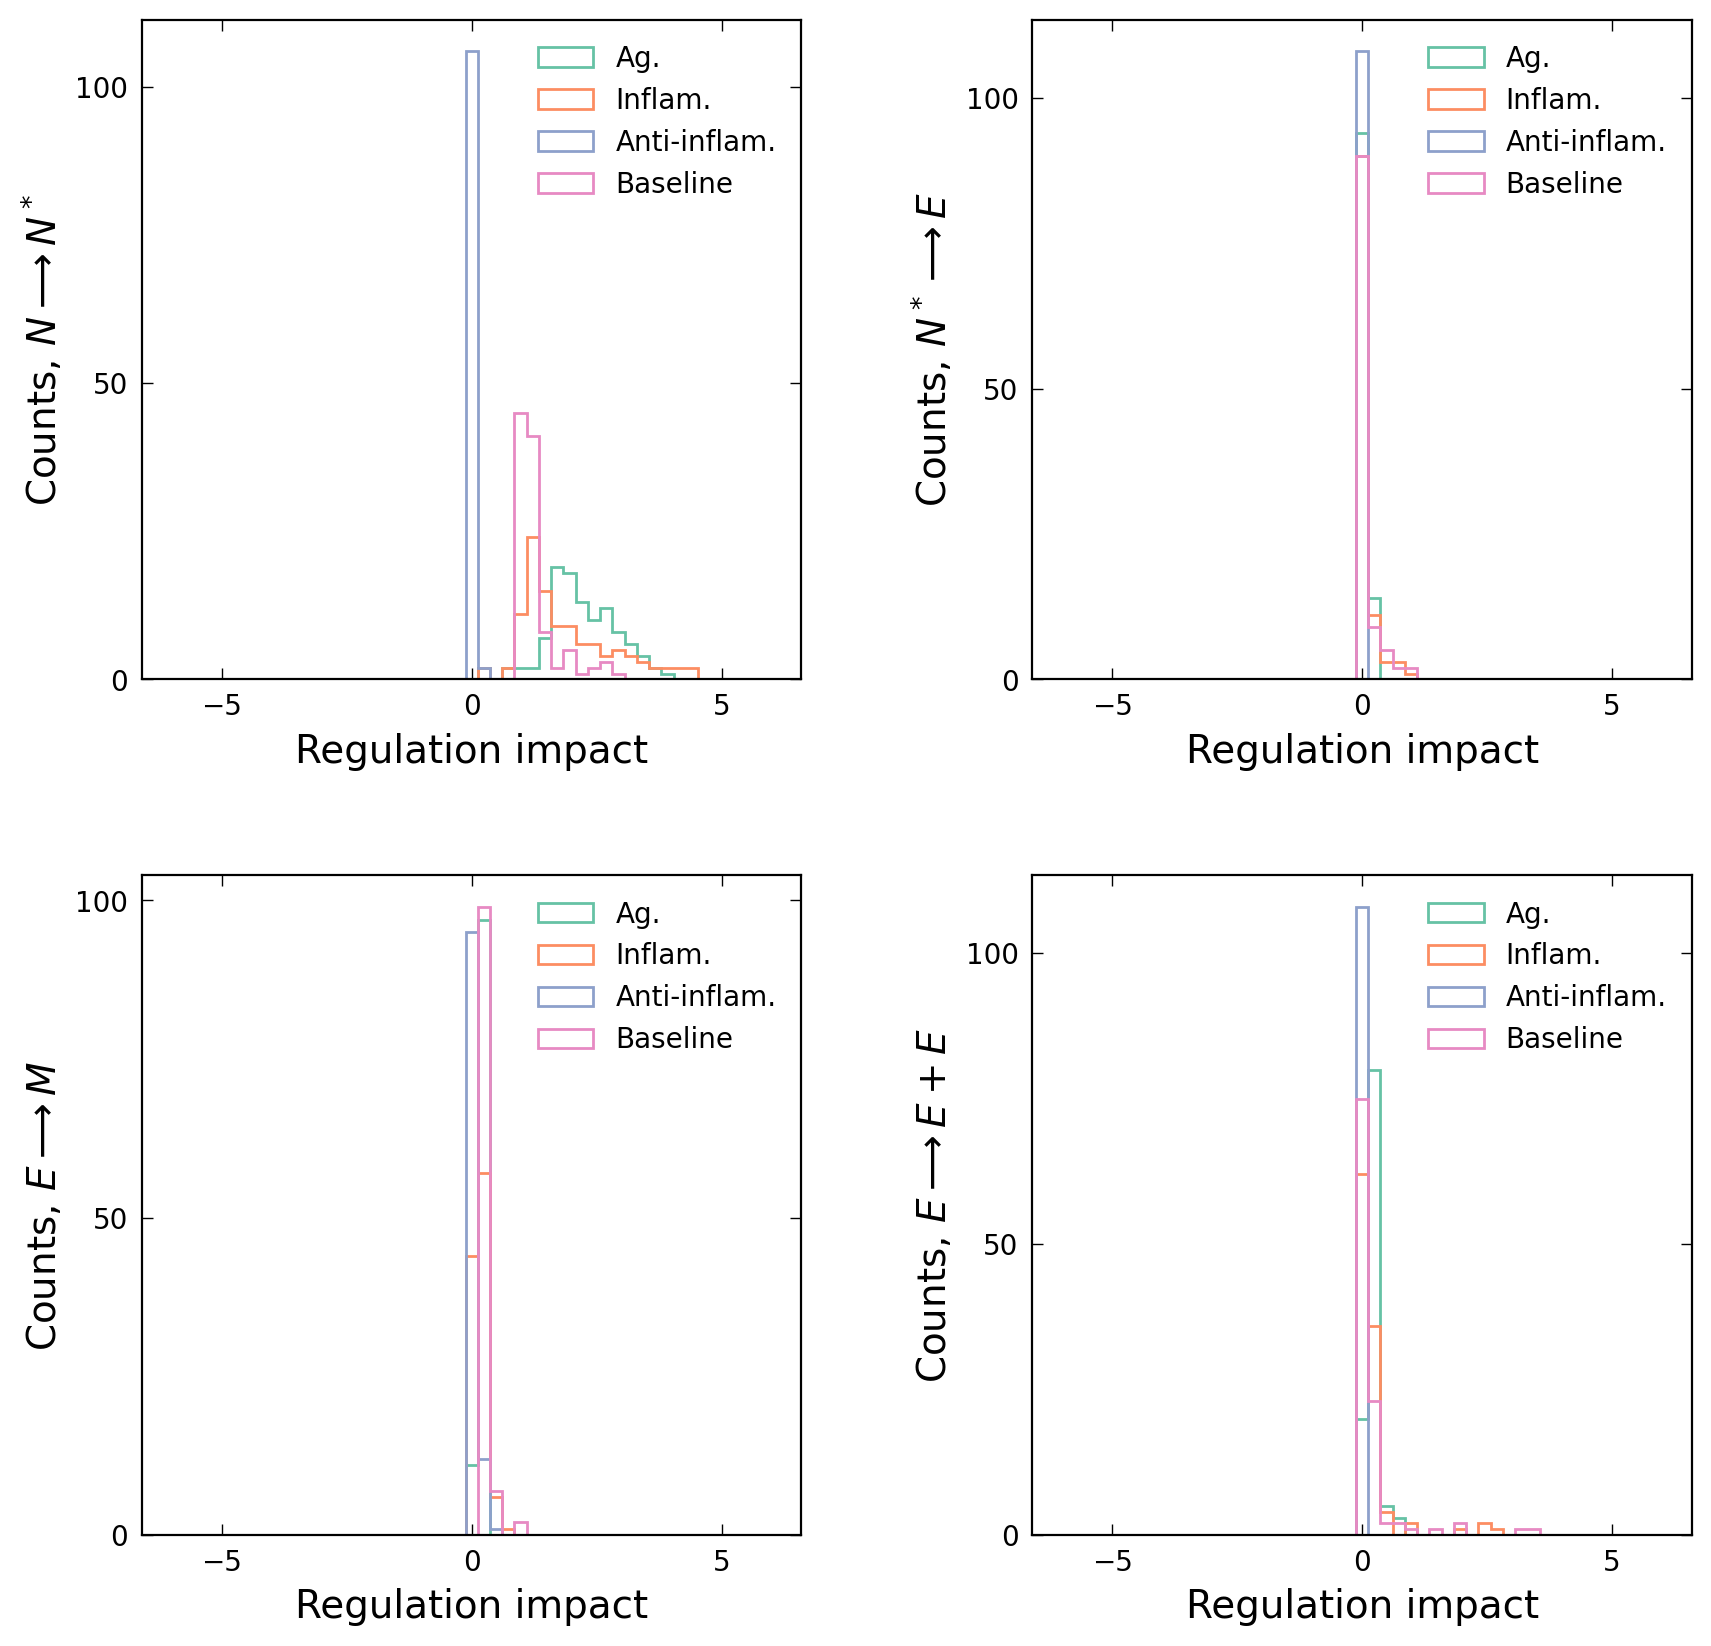

In [71]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-2.0*psi_max, 2.0*psi_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [72]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
3,16.719947,6.310639e-21,1.257575,0.149690,0.118501,1.842657,0.253711,0.036467,0.032230,0.429361,0.224221,0.011684,0.230351,0.482592,0.450389,0.039645,0.036810,0.673886,0.423769,1.609503,2.346647,-0.717991,0.036497,0.003265,0.007126,0.003372,0.003345,0.009441,0.002574,0.002321,0.002319,0.002430,0.003226,0.003030,0.003236,0.003547,0.002058,0.001564,0.001564,0.001900,0.003797,0.010417,0.015109,0.003135,0.01,10000000.0,0.0,50000.0,300.0,10000000.0,0.0,2.281849,12.566132,0.0,0.0,3.0,1.123444,3.517882,0.0,0.687654,0.060883,0.292531,NaN
8,7.650977,1.645361e-35,0.354333,0.191838,0.004498,2.845914,0.186140,0.000711,0.021636,1.017933,0.175343,0.001120,0.246553,1.075485,0.379820,0.023307,0.037169,3.283771,-4.732611,1.373516,3.690566,-12.000000,0.024990,0.000351,0.002302,0.002199,0.002148,0.021069,0.001984,0.001944,0.001945,0.002208,0.002483,0.002439,0.002524,0.003105,0.003336,0.001383,0.001397,0.027603,0.041788,0.004590,0.011478,0.107738,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.208247,7.650977,0.0,0.0,3.0,0.181771,0.894784,0.0,0.180540,0.060883,0.003880,NaN
13,16.757592,4.911467e-19,1.039616,0.639557,0.117813,1.572204,0.241344,0.145027,0.028521,0.438888,0.219786,0.051327,0.207487,0.487310,0.438869,0.170430,0.037849,0.682281,0.557078,1.596953,2.374493,-0.728352,0.037049,0.003492,0.005285,0.004141,0.003264,0.006312,0.002604,0.002460,0.002375,0.002447,0.003330,0.003149,0.003310,0.003713,0.002104,0.001698,0.001621,0.001990,0.004148,0.010353,0.015774,0.003210,0.05,10000000.0,0.0,50000.0,300.0,10000000.0,0.0,2.324220,12.691849,0.0,0.0,3.0,1.163624,3.539056,0.0,0.665597,0.267120,0.324858,NaN
18,8.331586,1.828367e-14,0.348952,0.691654,0.000535,2.640451,0.179309,0.001540,0.021664,0.987207,0.155498,0.005656,0.277983,0.996792,0.378965,0.146208,0.050981,3.332395,-4.084863,1.531864,3.475866,-12.000000,0.020935,0.000361,0.002293,0.002631,0.002095,0.007310,0.001730,0.001695,0.001696,0.001943,0.002114,0.002081,0.002181,0.002612,0.002925,0.001596,0.001370,0.022294,0.013687,0.004357,0.009696,0.086227,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.248927,8.331586,0.0,0.0,3.0,0.187263,1.044510,0.0,0.173276,0.267120,0.006105,NaN


In [73]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.I_0 > I_0)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
523,24.656086,1.450659e-24,1.429880,1.220163,0.078725,1.082158,0.191757,0.168080,0.011966,0.238189,0.215036,0.187813,0.146154,0.345662,0.190655,0.167131,0.012887,0.212777,1.802976,1.554465,1.918306,-0.087854,0.152928,0.009963,0.006909,0.006202,0.003323,0.004493,0.003032,0.002893,0.002398,0.003017,0.003072,0.002997,0.002900,0.003178,0.001608,0.001504,0.001078,0.001269,0.008245,0.018653,0.015473,0.010845,0.01,1000000.0,0.1,50000.0,300.0,10000000.0,1000000.0,5.014094,13.301758,0.0,5.413745,3.0,1.791573,4.346649,-4.090746e+10,1.270909,1.086098,0.358678,inf
528,24.780691,4.338898e-20,1.398658,1.198167,0.135437,1.065629,0.185265,0.161851,0.024963,0.232211,0.207749,0.183316,0.180240,0.335066,0.181931,0.159276,0.025912,0.206601,1.738502,1.527761,1.719738,-0.060925,0.161784,0.009816,0.006724,0.006043,0.003330,0.004372,0.003024,0.002879,0.002389,0.003034,0.002833,0.002767,0.002759,0.002823,0.001618,0.001512,0.001096,0.001306,0.007954,0.019124,0.013950,0.011525,0.01,1000000.0,0.1,50000.0,1000.0,10000000.0,1000000.0,4.916008,13.064520,0.0,5.288513,3.0,1.764245,4.262623,-4.090746e+10,1.242482,1.061715,0.567089,inf
533,13.101997,2.080990e-16,0.822902,3.062794,0.071168,2.610224,0.220016,0.825913,0.055606,0.711153,0.132097,0.505059,0.302260,0.571946,0.668125,2.371321,0.042525,1.851257,1.214806,1.750681,2.322641,-3.557270,0.012947,0.001532,0.004683,0.013128,0.003438,0.011016,0.002262,0.003096,0.002185,0.001918,0.002429,0.002953,0.002609,0.002418,0.003388,0.008358,0.002304,0.006349,0.004433,0.006103,0.009700,0.012084,0.01,10000000.0,0.1,50000.0,300.0,10000000.0,1000000.0,1.301032,12.144919,0.0,0.000000,3.0,0.697070,2.937171,-4.090746e+10,0.240990,1.116188,0.082027,6.698971
538,13.053965,1.594260e-16,0.809785,3.020505,0.126307,2.579601,0.216493,0.810409,0.091502,0.703241,0.128749,0.495190,0.409455,0.593941,0.677758,2.403858,0.089807,1.877246,1.187459,1.750361,2.222140,-3.564987,0.012859,0.001530,0.004694,0.013106,0.003487,0.011002,0.002280,0.003106,0.002214,0.001933,0.002391,0.002874,0.002724,0.002290,0.003482,0.008611,0.002380,0.006528,0.004413,0.006207,0.008938,0.012430,0.01,10000000.0,0.1,50000.0,1000.0,10000000.0,1000000.0,1.281329,11.953574,0.0,0.000000,3.0,0.696624,2.901179,-4.090746e+10,0.239684,1.113309,0.124508,6.698971
